# <center>**LC17 and LPLC2 Outputs - Male CNS**</center>

Direct connections from LC17 and from LPLC2 onto the descending neurons in the Male CNS.

In the Male CNS, LC17 synapses directly onto DNp35 (which also carries the annotation PVLP136), so checking what else is there, and how LPLC2 compares.

In [1]:
import os
import numpy as np
import pandas as pd

# Connectome
import connectome_analysis
import neuprint
from neuprint import NeuronCriteria as NC

# Plotting
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_style("ticks")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
dataset  = "malecns"
data_dir = f"../Data/Direct/{dataset}"
fig_dir  = f"../Figures/Direct/{dataset}"

# Folders
os.makedirs(data_dir, exist_ok = True)
os.makedirs(fig_dir,  exist_ok = True)

## Fetching the Connectivity to Descending Neurons

In [3]:
token = os.environ["HEMIBRAIN_TOKEN"]
malecns_analysis = connectome_analysis.neuPrintConnect(token   = token,
                                                       server  = "neuprint.janelia.org",
                                                       dataset = "male-cns:v1.0")

Client version : 1.9.3


Fetching connectivity.

In [4]:
sources = NC(type = ["LC17", "LPLC2"])
targets = NC(type = "DN.*", regex = True)

# Fetch connectivity
direct_df, _ = malecns_analysis.connectivity(sources,
                                             targets,
                                             min_weight = 0, # Zero here just to give a good broad survey, picks up very spurious things (good to see)!
                                             render     = False)

# Save it
direct_df.to_parquet(f"{data_dir}/LC17-LPLC2_DN-direct.parquet",
                        index = False,
                        engine = "pyarrow")

# Take a look
direct_df

Client("https://neuprint.janelia.org", "male-cns:v1.0")


  0%|          | 0/3 [00:00<?, ?it/s]

,bodyId_pre,type_pre,instance_pre,bodyId_post,type_post,instance_post,roi,weight
0,31563,LPLC2,LPLC2_L,10010,DNp01,DNp01(GF)_L,PVLP(L),64
1,22253,LPLC2,LPLC2_L,10010,DNp01,DNp01(GF)_L,PVLP(L),60
2,20182,LPLC2,LPLC2_R,10001,DNp01,DNp01(GF)_R,PVLP(R),59
3,24187,LPLC2,LPLC2_R,10923,DNg40,DNg40(hb5813056435)_R,PVLP(R),57
4,19787,LPLC2,LPLC2_L,10010,DNp01,DNp01(GF)_L,PVLP(L),55
...,...,...,...,...,...,...,...,...
2362,25136,LPLC2,LPLC2_L,10259,DNp11,DNp11_L,PVLP(L),1
2363,25136,LPLC2,LPLC2_L,10449,DNpe025,DNpe025(PVLP145)_L,PVLP(L),1
2364,25136,LPLC2,LPLC2_L,10931,DNpe045,DNpe045(DNp23)_L,PVLP(L),1
2365,25209,LPLC2,LPLC2_L,10783,DNp09,DNp09_L,PVLP(L),1


Group by Isntances!

In [5]:
# Convert to matrix
direct_matrix = pd.crosstab(direct_df.instance_pre, 
                            direct_df.instance_post,
                            values = direct_df.weight,
                            aggfunc = "sum")

# Sort the order
direct_matrix = direct_matrix.reindex(["LC17_L", "LC17_R", "LPLC2_L", "LPLC2_R"]).fillna(0).astype(int)


# Getting the columns - every DN type with both sides, alphabetically
cols     = direct_matrix.columns
new_cols = np.unique([col.rsplit("_", 1)[0] for col in cols])
new_cols = [f"{col}_{hem}" for col in new_cols for hem in ["L", "R"]]

# Re-columns - the side that nothing connects to gets a star
direct_matrix = direct_matrix.reindex(columns = new_cols).fillna(0).astype(int)
direct_matrix.columns = [col if col in cols else "*" + col for col in new_cols]

# Take a look
direct_matrix

,DNc02(SIFa)_L,DNc02(SIFa)_R,DNg40(hb5813056435)_L,DNg40(hb5813056435)_R,DNge032_L,*DNge032_R,DNge054_L,DNge054_R,DNp01(GF)_L,DNp01(GF)_R,...,DNpe037(CL338)_L,*DNpe037(CL338)_R,DNpe042(CL262)_L,DNpe042(CL262)_R,DNpe045(DNp23)_L,DNpe045(DNp23)_R,DNpe052(AVLP564)_L,DNpe052(AVLP564)_R,DNpe056(PVLP146)_L,DNpe056(PVLP146)_R
instance_pre,,,,,,,,,,,,,,,,,,,,,
LC17_L,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
LC17_R,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
LPLC2_L,0,3,1172,0,4,0,30,0,2642,0,...,5,0,276,0,132,0,114,0,874,0
LPLC2_R,0,0,0,1826,0,0,0,33,0,2220,...,0,0,0,246,0,190,0,31,0,745


Plotting the heatmap.

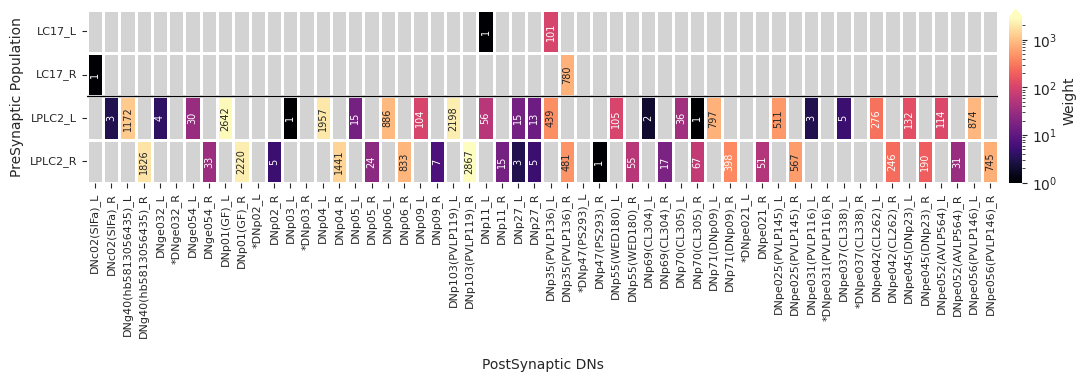

In [6]:
fig, ax = plt.subplots(figsize = (14, 2.25))

ax.set_facecolor("lightgrey")
# Place heatmap
sns.heatmap(direct_matrix,
            norm = LogNorm(1, direct_matrix.values.max()),
            cmap = "magma",
            mask = direct_matrix == 0,
            linewidths = 1,
            annot = True,
            fmt   = "d",
            annot_kws = {"rotation" : 90,
                         "size"     : 7},
            cbar_kws  = {"label"  : "Weight",
                         "shrink" : 1,
                         "pad"    : 0.01,
                         "extend" : "max",
                         "aspect" : 13},
            xticklabels = True)

# Split LC17 and LPLC2
ax.axhline(2, color = "black", linewidth = 1)

# Labels
ax.set_ylabel("PreSynaptic Population", fontsize = 10)
ax.set_xlabel("PostSynaptic DNs", labelpad = 15, fontsize = 10)

# Tick params
ax.tick_params(axis = "both", labelsize = 8)

# Save
plt.savefig(f"{fig_dir}/{dataset}_LC17-LPLC2_DN-Direct.pdf",
            dpi = 600,
            bbox_inches = "tight")
plt.savefig(f"{fig_dir}/{dataset}_LC17-LPLC2_DN-Direct.png",
            dpi = 600,
            bbox_inches = "tight")

## Outputs and Recurrence

In [7]:
# Fetch connectivity
out_df, _ = malecns_analysis.connectivity(sources,
                                          min_weight = 0, # Zero again here!
                                          render = False)

# Save it
out_df.to_parquet(f"{data_dir}/LC17-LPLC2_Outputs.parquet",
                    index = False,
                    engine = "pyarrow")

# Take a look
out_df

Client("https://neuprint.janelia.org", "male-cns:v1.0")


  0%|          | 0/3 [00:00<?, ?it/s]

,bodyId_pre,type_pre,instance_pre,bodyId_post,type_post,instance_post,roi,weight
0,25772,LC17,LC17_R,11367,PVLP061,PVLP061_R,PVLP(R),328
1,25648,LC17,LC17_R,11367,PVLP061,PVLP061_R,PVLP(R),261
2,22435,LC17,LC17_R,11367,PVLP061,PVLP061_R,PVLP(R),256
3,32722,LC17,LC17_R,11367,PVLP061,PVLP061_R,PVLP(R),254
4,24409,LC17,LC17_R,11367,PVLP061,PVLP061_R,PVLP(R),249
...,...,...,...,...,...,...,...,...
106705,39097,LC17,LC17_R,14095,ANXXX250,ANXXX250(hb1722993253)_R,PVLP(R),1
106706,26863,LC17,LC17_R,40726,LC17,LC17_R,PVLP(R),1
106707,26863,LC17,LC17_R,39876,LC17,LC17_R,PVLP(R),1
106708,26863,LC17,LC17_R,38729,LC17,LC17_R,PVLP(R),1


Removing the outputs that are LC17s and LPLC2s

In [8]:
out_df = out_df.loc[~(out_df["type_post"] == "LC17") &
                    ~(out_df["type_post"] == "LPLC2")]

# Group by instance
out_grouped = out_df.groupby(["instance_pre",
                             "instance_post"])["weight"].sum().reset_index()

# Filtering the minimum weight > 10
out_grouped = out_grouped.loc[out_grouped["weight"] > 10].reset_index(drop = True)

# Take a look
out_grouped

,instance_pre,instance_post,weight
0,LC17_L,18981_L,479
1,LC17_L,26436_L,14
2,LC17_L,AVLP080_L,110
3,LC17_L,AVLP152_L,230
4,LC17_L,AVLP153_L,1222
...,...,...,...
751,LPLC2_R,Y12_R,33
752,LPLC2_R,Y13_R,43
753,LPLC2_R,Y14_R,15
754,LPLC2_R,Y3_R,373


Getting the output types and looking at their recurrent connectivity

In [9]:
out_instances = np.unique(out_grouped["instance_post"])
out_criteria = NC(instance = out_instances)

# Fetch connectivity
rec_df, _ = malecns_analysis.connectivity(out_criteria,
                                          sources,
                                          min_weight = 0, # Zero again here!
                                          render = False)

# Save it
rec_df.to_parquet(f"{data_dir}/LC17-LPLC2_Recurrence.parquet",
                    index = False,
                    engine = "pyarrow")

# Take a look
rec_df

Client("https://neuprint.janelia.org", "male-cns:v1.0")


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

,bodyId_pre,type_pre,instance_pre,bodyId_post,type_post,instance_post,roi,weight
0,16659,PVLP011,PVLP011_R,25772,LC17,LC17_R,PVLP(R),160
1,16659,PVLP011,PVLP011_R,32722,LC17,LC17_R,PVLP(R),142
2,523564,PVLP011,PVLP011_L,38591,LC17,LC17_L,PVLP(L),138
3,523564,PVLP011,PVLP011_L,523689,LC17,LC17_L,PVLP(L),137
4,16659,PVLP011,PVLP011_R,26131,LC17,LC17_R,PVLP(R),133
...,...,...,...,...,...,...,...,...
154679,73561,Tm33,Tm33_L,25781,LC17,LC17_L,LO(L),1
154680,73561,Tm33,Tm33_L,14030,LPLC2,LPLC2_L,LO(L),1
154681,73559,T2a,T2a_R,28273,LC17,LC17_R,LO(R),1
154682,73550,Tm5Y,Tm5Y_R,34566,LC17,LC17_R,LO(R),1


In [10]:
# Group by instance
rec_grouped = rec_df.groupby(["instance_pre",
                             "instance_post"])["weight"].sum().reset_index()

# Take a look
rec_grouped

,instance_pre,instance_post,weight
0,18628_R,LPLC2_R,4
1,18981_L,LC17_L,85
2,18981_R,LC17_R,5
3,76505_R,LPLC2_R,4
4,AVLP080_L,LC17_L,1154
...,...,...,...
706,Y3_L,LPLC2_L,4516
707,Y3_R,LC17_R,7400
708,Y3_R,LPLC2_R,5414
709,vCal3_L,LPLC2_L,32


### Recurrent vs Feedforward Partners

Merging the outputs with the inputs coming back, so every partner has both for each side of each population. Partners that send nothing back get an input of zero.

In [11]:
reciprocal = out_grouped.copy(deep = True)
reciprocal.rename(columns = {"weight" : "output"}, inplace = True)

# Merge
rec_mer = rec_grouped.copy(deep = True)
rec_mer.rename(columns = {"weight"        : "input",
                          "instance_pre"  : "instance_post",
                          "instance_post" : "instance_pre"}, # Inverting the names to merge correctly
               inplace = True)

# Merge 
reciprocal = reciprocal.merge(rec_mer,
                              on  = ["instance_pre", "instance_post"],
                              how = "left")

# Fill
reciprocal["input"] = reciprocal["input"].fillna(0).astype(int)

# Take a look
reciprocal

,instance_pre,instance_post,output,input
0,LC17_L,18981_L,479,85
1,LC17_L,26436_L,14,0
2,LC17_L,AVLP080_L,110,1154
3,LC17_L,AVLP152_L,230,3
4,LC17_L,AVLP153_L,1222,48
...,...,...,...,...
751,LPLC2_R,Y12_R,33,655
752,LPLC2_R,Y13_R,43,249
753,LPLC2_R,Y14_R,15,93
754,LPLC2_R,Y3_R,373,5414


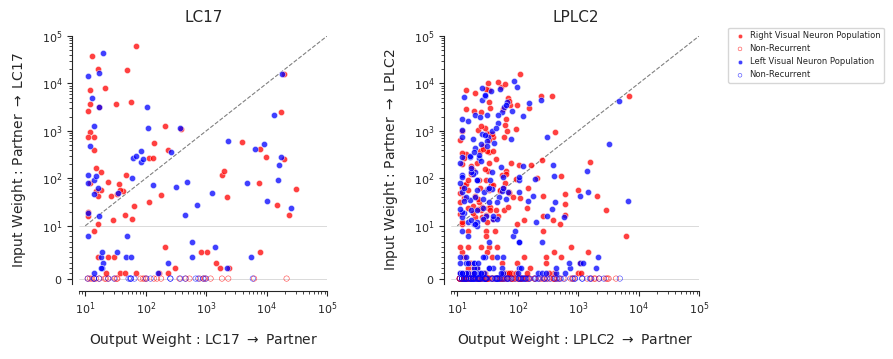

In [12]:
# Zeros can't sit on a log axis, so the y axis goes symlog
# Anything sitting on the floor is drawn hollow - nothing comes back
linthresh = 10

# Only label the partners getting at least this many synapses
label_min = 2000

# Colors
palette = {"R" : "red",
           "L" : "blue"}

fig, ax = plt.subplots(figsize = (8, 3.5), ncols = 2)
plt.subplots_adjust(wspace = 0.5)

#------------------------------------------------------------------
# LC17 on the left, LPLC2 on the right
for a, source in zip(ax, ["LC17", "LPLC2"]):
    for side, label in [("R", "Right"), ("L", "Left")]:
        # This population on this side - leaving out the unannotated partners
        x = reciprocal.loc[(reciprocal["instance_pre"] == f"{source}_{side}") &
                           (reciprocal["instance_post"] != "NA")]

        # Partners that send nothing back
        quiet = x["input"] == 0

        # Recurrent
        a.scatter(x["output"].loc[~quiet],
                  x["input"].loc[~quiet],
                  s = 20,
                  alpha = 0.75,
                  linewidth = 0.4,
                  edgecolor = "white",
                  label = f"{label} Visual Neuron Population",
                  color = palette[side],
                  zorder = 3)

        # Nothing back
        a.scatter(x["output"].loc[quiet],
                  x["input"].loc[quiet],
                  s = 15,
                  alpha = 0.75,
                  linewidth = 0.4,
                  facecolor = "none",
                  label = "Non-Recurrent",
                  edgecolor = palette[side],
                  zorder = 3)

#------------------------------------------------------------------
# Despine
for a in ax:
    # Reciprocity reads off position against the identity line
    a.plot([1e1, 1e5],
           [1e1, 1e5],
           color = "grey", linestyle = "--", linewidth = 0.8,
           zorder = 1)

    # Where the axis stops being logarithmic
    a.axhline(linthresh, color = "grey", linewidth = 0.5, alpha = 0.4)
    # Zero
    a.axhline(0, color = "grey", linewidth = 0.5, alpha = 0.4)

    # Adjust
    sns.despine(ax = a, offset = 5)
    a.set_xscale("log")
    a.set_yscale("symlog", linthresh = linthresh)
    a.set_xlim(8, 1e5)
    a.set_ylim(-1, 1e5)
    a.set_box_aspect(1)
    a.tick_params(axis = "both", labelsize = 8)

# Legend
ax[1].legend(fontsize = 6,
             loc = "upper left",
             bbox_to_anchor = (1.1, 1.05),
             markerscale = 0.7,
             handletextpad = 0.15)

#------------------------------------------------------------------
# Yticks for y axis
major = [0, 10, 100, 1000, 10000, 100000]
minor = list(range(1, 10))
for decade in major[1:-1]:
    minor += [n * decade for n in range(2, 10)]

ax[0].yaxis.set_major_locator(mticker.FixedLocator(major))
ax[0].yaxis.set_minor_locator(mticker.FixedLocator(minor))
ax[1].yaxis.set_major_locator(mticker.FixedLocator(major))
ax[1].yaxis.set_minor_locator(mticker.FixedLocator(minor))

#------------------------------------------------------------------
# Titles
ax[0].set_title("LC17", fontsize = 11, pad = 10)
ax[1].set_title("LPLC2", fontsize = 11, pad = 10)

# Labels
ax[0].set_xlabel("Output Weight : LC17 $\\rightarrow$ Partner", labelpad = 10)
ax[1].set_xlabel("Output Weight : LPLC2 $\\rightarrow$ Partner", labelpad = 10)
ax[0].set_ylabel("Input Weight : Partner $\\rightarrow$ LC17", labelpad = 10)
ax[1].set_ylabel("Input Weight : Partner $\\rightarrow$ LPLC2", labelpad = 10)

# Save
plt.savefig(f"{fig_dir}/{dataset}_LC17-LPLC2_Output-vs-Input.pdf",
            dpi = 600,
            bbox_inches = "tight")
plt.savefig(f"{fig_dir}/{dataset}_LC17-LPLC2_Output-vs-Input.png",
            dpi = 600,
            bbox_inches = "tight")

# <center>**हो गया दोस्तों**</center>